In [164]:
# Uncomment on the first try if there's error with using ydata-profiling and ipywidgets
#import sys
#print(sys.executable)
#!"{sys.executable}" -m pip install ydata-profiling
#!"{sys.executable}" -m pip install ipywidgets
#!"{sys.executable}" -m pip install tensorflow 

In [165]:
# Importing dependency
from ydata_profiling import ProfileReport
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
%matplotlib inline


# Importing dataset
df = pd.read_csv(r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\labels.csv")

# Data Sourcing and Exploration

In [166]:
# Dataset Identification: Basic Audit
def dataset_audit_report(df, title='Dataset Audit Report'):
    return ProfileReport(df, title=title)

# Run audit and view
report = dataset_audit_report(df)
report

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 26.02it/s]


label
surprise    4616
happy       4336
anger       3608
disgust     3472
contempt    3244
fear        3043
sad         2995
neutral     2861
Name: count, dtype: int64 

label
surprise    16.383319
happy       15.389530
anger       12.805679
disgust     12.322981
contempt    11.513753
fear        10.800355
sad         10.629991
neutral     10.154392
Name: proportion, dtype: float64 



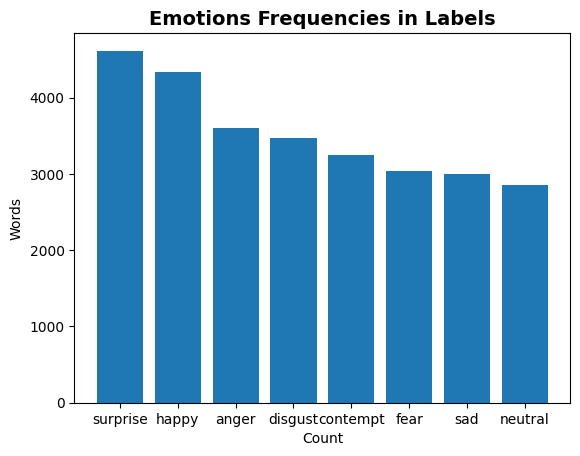

In [167]:
# Check Emotion Frequency
def check_emotion_frequency(df):
    return  df['label'].str.lower().str.split().explode().value_counts()

# Check emotion representation in percent; Also already in the Data Audit Report 
def check_emotion_representation(df):
    return  df['label'].value_counts(normalize=True) * 100


# Word Counts
raw_word_counts = check_emotion_frequency(df)
print(raw_word_counts, "\n")

percentage_word_counts = check_emotion_representation(df)
print(percentage_word_counts, "\n")


# Plotting the raw frequency for each emotions
word_counts_plotting = raw_word_counts.to_dict()
emotion = list(word_counts_plotting.keys())
count = list(word_counts_plotting.values())

fig, ax = plt.subplots()
ax.bar(emotion, count)
ax.set_title('Emotions Frequencies in Labels', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Words')
plt.show()


In [168]:
# Percentage Difference
def percentage_difference(v1,v2):
    return ((v1 - v2) / ( (v1 + v2) / 2)) * 100

# Raw Value
print("The average value is ", raw_word_counts.mean())
print("The median value is ", raw_word_counts.median())
print("The raw difference between the maximum and minimum frequency is ", raw_word_counts.max() - raw_word_counts.min(), "\n")

# Proportion
print("The percentage difference between the maximum and minimum frequency is ", percentage_difference(raw_word_counts.max(), raw_word_counts.min()), "\n")

The average value is  3521.875
The median value is  3358.0
The raw difference between the maximum and minimum frequency is  1755 

The percentage difference between the maximum and minimum frequency is  46.943961481877764 



**Insight**: Mild class imbalance representation (10.2%–16.4% across emotion categories)

*Consideration*:
- Will apply data augmentation to the bottom category (fear, sad, neutral), increasing it to the median value (3358.0). Average was not used due to the relative high difference between the maximum and minimum frequency (46.94%). 

- No removal of image, as not to reduce the total amount of information available to the model.
- Demographic concern exist as demographic information is unavailable and analysis couldn't be performed based on the dataset alone. An alternative would be using FairFace or other model. However, this relies on a model to determine the demograhic, which may or may not have it's own bias

In [169]:
print(df.groupby("label")["relFCs"].describe())

           count      mean       std       min       25%       50%       75%  \
label                                                                          
anger     3608.0  0.804666  0.059620  0.517029  0.772433  0.815451  0.848712   
contempt  3244.0  0.806261  0.055090  0.540322  0.773961  0.815529  0.847071   
disgust   3472.0  0.802862  0.058786  0.539389  0.769194  0.812828  0.847047   
fear      3043.0  0.812260  0.057289  0.519077  0.784175  0.821046  0.852851   
happy     4336.0  0.783044  0.056817  0.548975  0.750922  0.792571  0.824013   
neutral   2861.0  0.794944  0.059738  0.535829  0.761627  0.805043  0.838927   
sad       2995.0  0.802395  0.056804  0.549557  0.769456  0.811298  0.844003   
surprise  4616.0  0.794630  0.059996  0.516357  0.759948  0.804036  0.838279   

               max  
label               
anger     0.899706  
contempt  0.899948  
disgust   0.899694  
fear      0.899852  
happy     0.898344  
neutral   0.899817  
sad       0.899951  
surprise  

**Insight:** relFCs is not a major source of bias. Looking at the means, difference between the highest and lowest means is 0.029, with the standard deviations are almost identical (~0.055–0.060).

# Data Augmentation

Aiming to use small augmentation what would still preserve the expression, such as horizontal flip, rotation, brightness/contrast, zoom, crop, and very light blur


**Citation:** 
- https://www.youtube.com/watch?v=WSvpLUietIM
- https://www.youtube.com/watch?v=14syUbL16k4



In [271]:
Target_Frequency = raw_word_counts.median()
PlotCount = 3


def plotImage(image_arr, image_count):
    fig, axes = plt.subplots(1,image_count, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip(image_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()    

In [ ]:
# Image Data Generator 
gen = ImageDataGenerator(rotation_range=10, 
                         width_shift_range=0.1,
                         height_shift_range=0.1, 
                         zoom_range=0.1,
                         #brightness_range=[0.9, 1], # Causing issue with neutral image being black 
                         horizontal_flip=True)

In [ ]:
# Choose random image from the given directory
fear = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\fear"
sad = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\sad"
neutral = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\neutral"


random_fear_image = random.choice(os.listdir(fear))
random_sad_image = random.choice(os.listdir(sad))
random_neutral_image = random.choice(os.listdir(neutral))

# Establish path and check existance
image_fear_path = fear + '\\' + random_fear_image
print(image_fear_path)

image_sad_path = sad + '\\'  + random_sad_image
print(image_sad_path)

image_neutral_path = neutral + '\\' + random_neutral_image
print(image_neutral_path)


assert os.path.isfile(image_fear_path)
assert os.path.isfile(image_sad_path)
assert os.path.isfile(image_neutral_path)


C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\fear\image0035737.jpg
C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\sad\image0024712.jpg
C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\neutral\ffhq_2671.png


Text(0.5, 1.0, 'Fear')

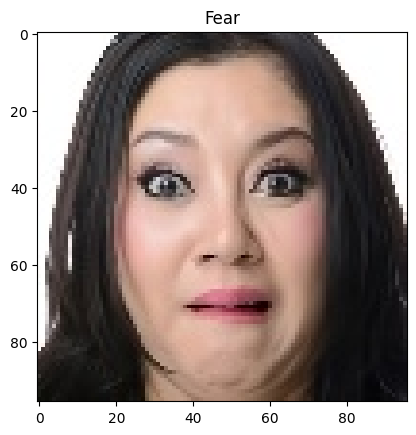

In [ ]:
# Obtain Image and Plot
fear_image = np.expand_dims(plt.imread(image_fear_path),0)
plt.imshow(fear_image[0])
plt.title("Fear")


Text(0.5, 1.0, 'Sad')

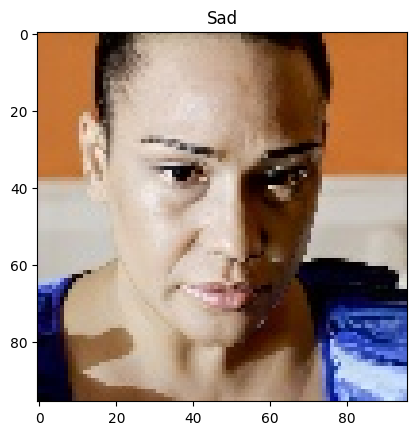

In [ ]:
sad_image = np.expand_dims(plt.imread(image_sad_path),0)
plt.imshow(sad_image[0])
plt.title("Sad")



Text(0.5, 1.0, 'Neutral')

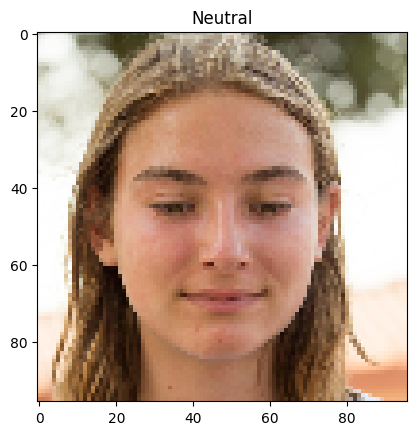

In [ ]:
neutral_image = np.expand_dims(plt.imread(image_neutral_path),0)
plt.imshow(neutral_image[0])
plt.title("Neutral")


In [312]:
# Generate bunch of augmented images
fear_aug_iter = gen.flow(fear_image)
sad_aug_iter = gen.flow(sad_image)
neutral_aug_iter = gen.flow(neutral_image)



In [314]:
# Get multiple samples of the augmented images
fear_aug_images = [next(fear_aug_iter)[0].astype(np.uint8) for i in range(PlotCount)]
sad_aug_images = [next(sad_aug_iter)[0].astype(np.uint8) for i in range(PlotCount)]
neutral_aug_images = [next(neutral_aug_iter)[0] for i in range(PlotCount)]


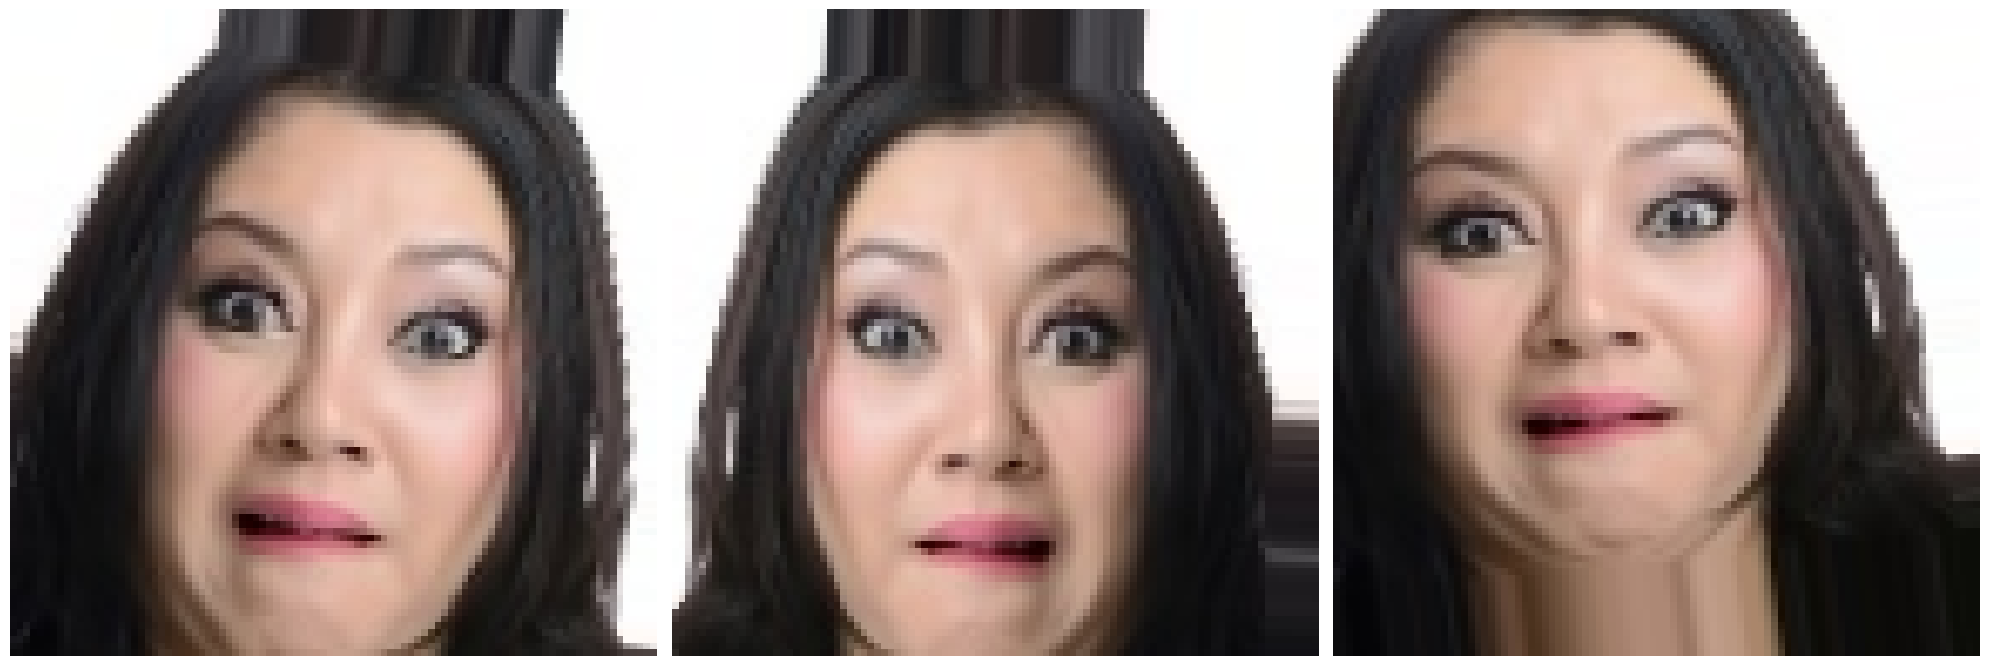

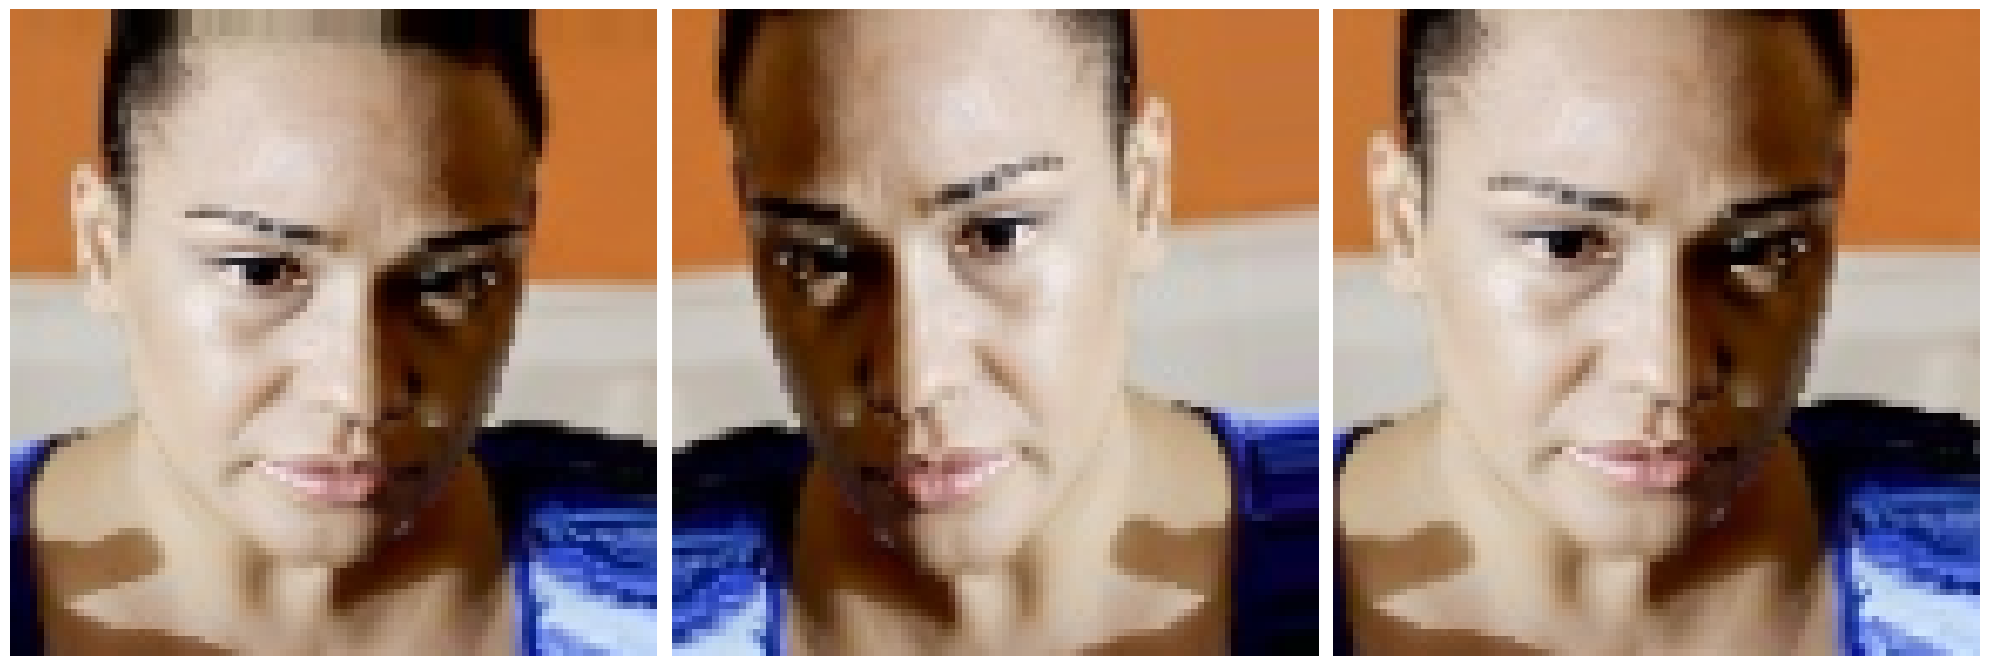

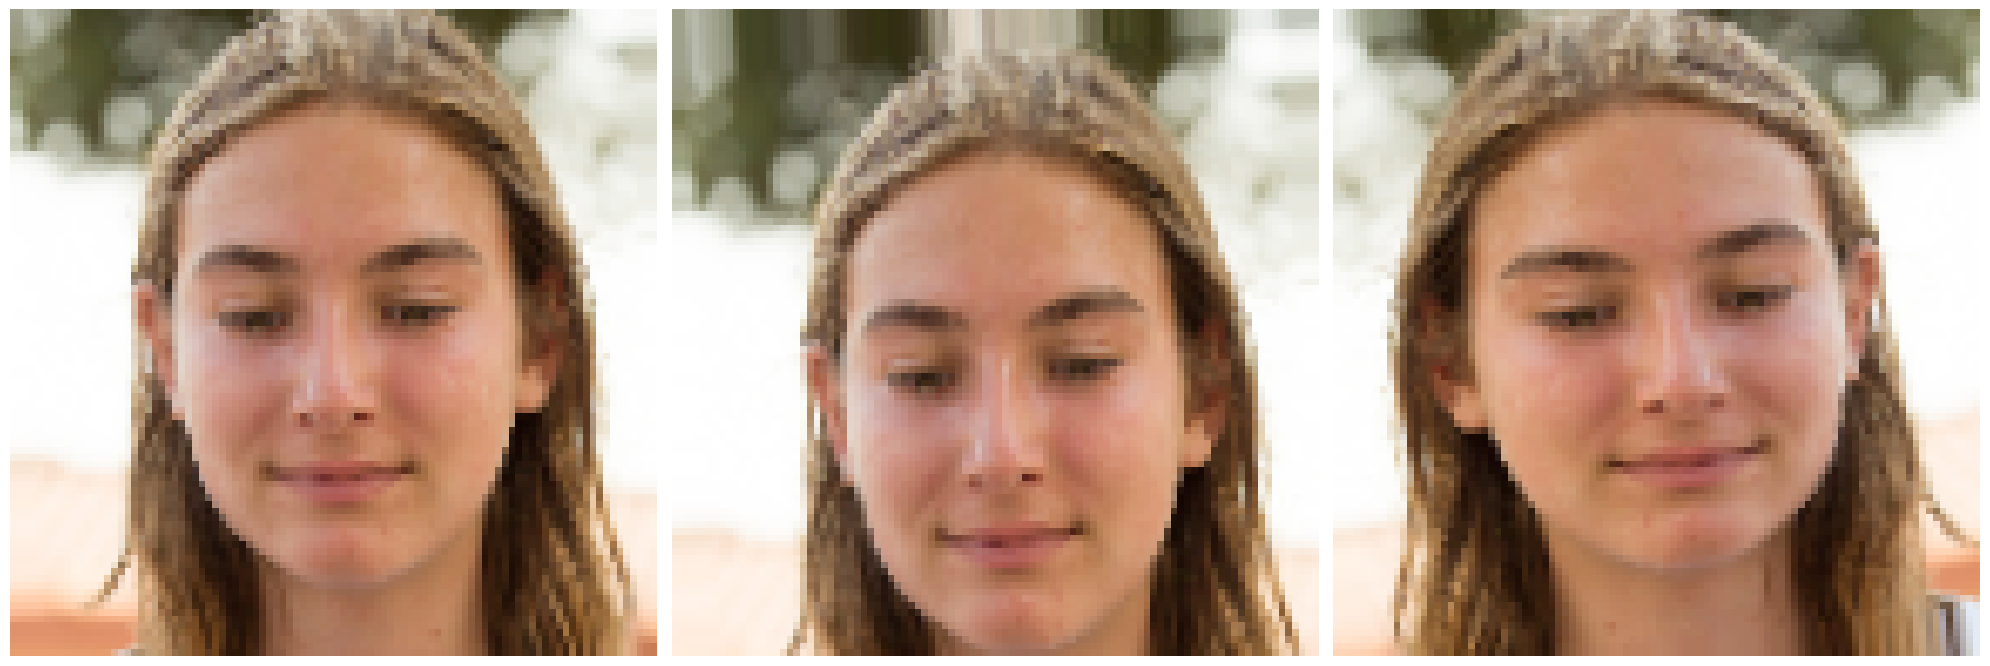

In [315]:
plotImage(fear_aug_images, PlotCount)
plotImage(sad_aug_images, PlotCount)
plotImage(neutral_aug_images, PlotCount)

Saving Processed Image

In [ ]:
fear_augmented = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\fear_augmented"
sad_augmented = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\sad_augmented"
neutral_augmented = r"C:\Users\Rocelyn Young\Downloads\archive (7)\archive (3)\Train\neutral_augmented"


def saving_images(aug_images, image_number, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for i, img in enumerate(aug_images):
        plt.imsave(
            os.path.join(output_dir, f"neutral_{i}.png"),
            img
        )
    plt.imsaved(r""
                neutral_aug_images[0])